In [5]:
import pandas as pd

df = pd.read_csv("cleaned_data.csv")
df.head()

,year,u_volumen,tkt_code,order_code,truck_code,ship_plant_code,delv_qty,plant_name,u_day,typed_time,...,scheduled_dt,dispatch_delay_min,order_instance,trip_end_dt,next_dispatch_dt,overlap_flag,flag_delay_outlier,dispatch_hour,dispatch_date,dow
0,2025,5.5,51278165,1163,6161,512,5.5,Chihuahua,11,05:38:00,...,2025-11-11 07:15:00,-97.0,1163_2025-11-11,2025-11-11 07:11:00,2025-11-11 09:22:00,False,False,5,2025-11-11,Tuesday
1,2025,1.0,51278197,1280,6161,512,1.0,Chihuahua,11,09:22:00,...,2025-11-11 11:15:00,-113.0,1280_2025-11-11,2025-11-11 10:25:00,2025-11-11 10:25:00,False,False,9,2025-11-11,Tuesday
2,2025,4.5,51278209,1079,6161,512,4.5,Chihuahua,11,10:25:00,...,2025-11-11 11:15:00,-50.0,1079_2025-11-11,2025-11-11 12:01:00,2025-11-11 12:08:00,False,False,10,2025-11-11,Tuesday
3,2025,7.0,51278220,1055,6161,512,7.0,Chihuahua,11,12:08:00,...,2025-11-11 13:00:00,-52.0,1055_2025-11-11,2025-11-11 13:38:00,2025-11-12 08:11:00,False,False,12,2025-11-11,Tuesday
4,2025,1.0,51278260,1250,6161,512,1.0,Chihuahua,12,08:11:00,...,2025-11-12 10:30:00,-139.0,1250_2025-11-12,2025-11-12 09:32:00,2025-11-12 14:50:00,False,False,8,2025-11-12,Wednesday


In [6]:
df.shape

(8560, 31)

In [7]:
# Conteo de registros por truck_code
conteo_truck_code = df["truck_code"].value_counts(dropna=False)
print(conteo_truck_code)

# (Opcional) cantidad de códigos únicos
print(f"\nCódigos únicos de truck_code: {df['truck_code'].nunique()}")

truck_code
12863    933
13221    920
9429     848
7044     736
13022    678
6302     589
6162     503
6603     498
9631     492
7046     440
6608     338
13014    338
13218    267
13011    259
6611     222
9428     218
7039     171
13219     52
6600      37
6161      21
Name: count, dtype: int64

Códigos únicos de truck_code: 20


In [8]:
df_overlap = df.loc[df["overlap_flag"] == True]

print(f"Registros con overlap_flag = True: {len(df_overlap)}")
df_overlap

Registros con overlap_flag = True: 17


,year,u_volumen,tkt_code,order_code,truck_code,ship_plant_code,delv_qty,plant_name,u_day,typed_time,...,scheduled_dt,dispatch_delay_min,order_instance,trip_end_dt,next_dispatch_dt,overlap_flag,flag_delay_outlier,dispatch_hour,dispatch_date,dow
1303,2025,2.0,51272528,1176,6603,512,2.0,Chihuahua,29,12:10:00,...,2025-07-29 16:15:00,-245.0,1176_2025-07-29,2025-07-29 13:20:00,2025-07-29 12:11:00,True,False,12,2025-07-29,Tuesday
1452,2025,6.0,51275618,1065,6603,512,6.0,Chihuahua,30,11:50:00,...,2025-09-30 10:00:00,110.0,1065_2025-09-30,2025-09-30 13:01:00,2025-09-30 12:55:00,True,False,11,2025-09-30,Tuesday
1464,2025,1.0,51275838,1315,6603,512,1.0,Chihuahua,3,11:38:00,...,2025-10-03 11:30:00,8.0,1315_2025-10-03,2025-10-03 13:19:00,2025-10-03 13:18:00,True,False,11,2025-10-03,Friday
1796,2025,4.0,51274573,1094,6608,512,4.0,Chihuahua,10,07:51:00,...,2025-09-10 08:00:00,-9.0,1094_2025-09-10,2025-09-10 08:41:00,2025-09-10 08:40:00,True,False,7,2025-09-10,Wednesday
1973,2026,1.0,51281029,1245,6608,512,1.0,Chihuahua,2,13:30:00,...,2026-01-02 14:45:00,-75.0,1245_2026-01-02,2026-01-02 14:49:00,2026-01-02 14:43:00,True,False,13,2026-01-02,Friday
2406,2025,1.5,51264776,1111,7044,512,1.5,Chihuahua,13,13:15:00,...,2025-03-13 13:45:00,-30.0,1111_2025-03-13,2025-03-13 14:05:00,2025-03-13 14:01:00,True,False,13,2025-03-13,Thursday
2683,2025,4.0,51272850,1185,7044,512,4.0,Chihuahua,6,07:50:00,...,2025-08-06 08:30:00,-40.0,1185_2025-08-06,2025-08-06 09:39:00,2025-08-06 08:19:00,True,False,7,2025-08-06,Wednesday
2759,2025,0.5,51273890,1379,7044,512,0.5,Chihuahua,27,09:49:00,...,2025-08-27 10:15:00,-26.0,1379_2025-08-27,2025-08-27 11:16:00,2025-08-27 11:07:00,True,False,9,2025-08-27,Wednesday
3350,2025,7.0,51271611,1357,7046,512,7.0,Chihuahua,10,11:37:00,...,2025-07-10 10:00:00,97.0,1357_2025-07-10,2025-07-10 12:45:00,2025-07-10 12:38:00,True,False,11,2025-07-10,Thursday
3908,2025,7.0,51267051,1095,9429,512,7.0,Chihuahua,17,08:39:00,...,2025-04-17 09:15:00,-36.0,1095_2025-04-17,2025-04-17 10:25:00,2025-04-17 10:23:00,True,False,8,2025-04-17,Thursday


In [9]:
# Eliminar registros con overlap_flag = True
df = df.loc[~df["overlap_flag"].fillna(False)].reset_index(drop=True)

# Verificación rápida
print(f"Nuevo tamaño de df: {df.shape}")
print(f"Registros con overlap_flag=True restantes: {(df['overlap_flag'] == True).sum()}")

Nuevo tamaño de df: (8543, 31)
Registros con overlap_flag=True restantes: 0


In [10]:
df_overlap = df.loc[df["flag_delay_outlier"] == True]

print(f"Registros con flag_delay_outlier = True: {len(df_overlap)}")
df_overlap

Registros con flag_delay_outlier = True: 14


,year,u_volumen,tkt_code,order_code,truck_code,ship_plant_code,delv_qty,plant_name,u_day,typed_time,...,scheduled_dt,dispatch_delay_min,order_instance,trip_end_dt,next_dispatch_dt,overlap_flag,flag_delay_outlier,dispatch_hour,dispatch_date,dow
487,2025,5.0,51280394,1012,6162,512,5.0,Chihuahua,17,14:54:00,...,2025-12-17 08:30:00,384.0,1012_2025-12-17,2025-12-17 16:38:00,2025-12-18 07:46:00,False,True,14,2025-12-17,Wednesday
637,2025,6.5,51267304,1413,6302,512,6.5,Chihuahua,23,16:35:00,...,2025-04-23 09:00:00,455.0,1413_2025-04-23,2025-04-23 17:39:00,2025-04-24 09:00:00,False,True,16,2025-04-23,Wednesday
1647,2025,7.0,51272237,1038,6608,512,7.0,Chihuahua,23,12:01:00,...,2025-07-23 05:00:00,421.0,1038_2025-07-23,2025-07-23 13:46:00,2025-07-23 14:05:00,False,True,12,2025-07-23,Wednesday
3120,2025,1.0,51264567,1271,7046,512,1.0,Chihuahua,11,09:30:00,...,2025-03-11 16:30:00,-420.0,1271_2025-03-11,2025-03-11 10:41:00,2025-03-11 10:47:00,False,True,9,2025-03-11,Tuesday
3390,2025,7.0,51272238,1038,7046,512,7.0,Chihuahua,23,12:15:00,...,2025-07-23 05:00:00,435.0,1038_2025-07-23,2025-07-23 13:56:00,2025-07-23 13:58:00,False,True,12,2025-07-23,Wednesday
3668,2025,6.5,51267301,1413,9428,512,6.5,Chihuahua,23,16:04:00,...,2025-04-23 09:00:00,424.0,1413_2025-04-23,2025-04-23 17:10:00,2025-04-24 07:15:00,False,True,16,2025-04-23,Wednesday
5594,2025,7.0,51272235,1038,12863,512,7.0,Chihuahua,23,11:10:00,...,2025-07-23 05:00:00,370.0,1038_2025-07-23,2025-07-23 12:38:00,2025-07-23 15:25:00,False,True,11,2025-07-23,Wednesday
5764,2025,0.5,51275054,1439,12863,512,0.5,Chihuahua,19,14:49:00,...,2025-09-19 06:00:00,529.0,1439_2025-09-19,2025-09-19 15:45:00,2025-09-20 08:37:00,False,True,14,2025-09-19,Friday
5931,2025,1.0,51278821,1149,12863,512,1.0,Chihuahua,21,09:54:00,...,2025-11-21 17:15:00,-441.0,1149_2025-11-21,2025-11-21 11:19:00,2025-11-21 13:44:00,False,True,9,2025-11-21,Friday
6593,2025,5.0,51280545,1015,13014,512,5.0,Chihuahua,19,14:59:00,...,2025-12-19 08:30:00,389.0,1015_2025-12-19,2025-12-19 16:45:00,2025-12-24 07:35:00,False,True,14,2025-12-19,Friday


In [11]:
# Eliminar registros con flag_delay_outlier = True
df = df.loc[~df["flag_delay_outlier"].fillna(False)].reset_index(drop=True)

# Verificación rápida
print(f"Nuevo tamaño de df: {df.shape}")
print(f"Registros con flag_delay_outlier=True restantes: {(df['flag_delay_outlier'] == True).sum()}")

Nuevo tamaño de df: (8529, 31)
Registros con flag_delay_outlier=True restantes: 0


In [12]:
df = df.drop(columns=["overlap_flag", "flag_delay_outlier"])
df.head()

,year,u_volumen,tkt_code,order_code,truck_code,ship_plant_code,delv_qty,plant_name,u_day,typed_time,...,start_time,dispatch_dt,scheduled_dt,dispatch_delay_min,order_instance,trip_end_dt,next_dispatch_dt,dispatch_hour,dispatch_date,dow
0,2025,5.5,51278165,1163,6161,512,5.5,Chihuahua,11,05:38:00,...,07:15:00,2025-11-11 05:38:00,2025-11-11 07:15:00,-97.0,1163_2025-11-11,2025-11-11 07:11:00,2025-11-11 09:22:00,5,2025-11-11,Tuesday
1,2025,1.0,51278197,1280,6161,512,1.0,Chihuahua,11,09:22:00,...,11:15:00,2025-11-11 09:22:00,2025-11-11 11:15:00,-113.0,1280_2025-11-11,2025-11-11 10:25:00,2025-11-11 10:25:00,9,2025-11-11,Tuesday
2,2025,4.5,51278209,1079,6161,512,4.5,Chihuahua,11,10:25:00,...,11:15:00,2025-11-11 10:25:00,2025-11-11 11:15:00,-50.0,1079_2025-11-11,2025-11-11 12:01:00,2025-11-11 12:08:00,10,2025-11-11,Tuesday
3,2025,7.0,51278220,1055,6161,512,7.0,Chihuahua,11,12:08:00,...,13:00:00,2025-11-11 12:08:00,2025-11-11 13:00:00,-52.0,1055_2025-11-11,2025-11-11 13:38:00,2025-11-12 08:11:00,12,2025-11-11,Tuesday
4,2025,1.0,51278260,1250,6161,512,1.0,Chihuahua,12,08:11:00,...,10:30:00,2025-11-12 08:11:00,2025-11-12 10:30:00,-139.0,1250_2025-11-12,2025-11-12 09:32:00,2025-11-12 14:50:00,8,2025-11-12,Wednesday


In [13]:
df = df.drop(columns=["ship_plant_code", "plant_name"])
df.head()

,year,u_volumen,tkt_code,order_code,truck_code,delv_qty,u_day,typed_time,at_plant_time,u_cicle,...,start_time,dispatch_dt,scheduled_dt,dispatch_delay_min,order_instance,trip_end_dt,next_dispatch_dt,dispatch_hour,dispatch_date,dow
0,2025,5.5,51278165,1163,6161,5.5,11,05:38:00,07:11:45,93.0,...,07:15:00,2025-11-11 05:38:00,2025-11-11 07:15:00,-97.0,1163_2025-11-11,2025-11-11 07:11:00,2025-11-11 09:22:00,5,2025-11-11,Tuesday
1,2025,1.0,51278197,1280,6161,1.0,11,09:22:00,10:25:27,63.0,...,11:15:00,2025-11-11 09:22:00,2025-11-11 11:15:00,-113.0,1280_2025-11-11,2025-11-11 10:25:00,2025-11-11 10:25:00,9,2025-11-11,Tuesday
2,2025,4.5,51278209,1079,6161,4.5,11,10:25:00,12:01:35,96.0,...,11:15:00,2025-11-11 10:25:00,2025-11-11 11:15:00,-50.0,1079_2025-11-11,2025-11-11 12:01:00,2025-11-11 12:08:00,10,2025-11-11,Tuesday
3,2025,7.0,51278220,1055,6161,7.0,11,12:08:00,13:38:09,90.0,...,13:00:00,2025-11-11 12:08:00,2025-11-11 13:00:00,-52.0,1055_2025-11-11,2025-11-11 13:38:00,2025-11-12 08:11:00,12,2025-11-11,Tuesday
4,2025,1.0,51278260,1250,6161,1.0,12,08:11:00,09:32:08,81.0,...,10:30:00,2025-11-12 08:11:00,2025-11-12 10:30:00,-139.0,1250_2025-11-12,2025-11-12 09:32:00,2025-11-12 14:50:00,8,2025-11-12,Wednesday


In [14]:
df["mes"] = pd.to_datetime(df["dispatch_dt"], errors="coerce").dt.month

df[["dispatch_dt", "mes"]].head()

,dispatch_dt,mes
0,2025-11-11 05:38:00,11
1,2025-11-11 09:22:00,11
2,2025-11-11 10:25:00,11
3,2025-11-11 12:08:00,11
4,2025-11-12 08:11:00,11


In [15]:
# Asegurar que df exista aunque esta celda se ejecute antes que las anteriores
if "df" not in globals():
    if "pd" not in globals():
        import pandas as pd
    df = pd.read_csv("cleaned_data.csv")

# Validar si los campos de día/fecha coinciden con dispatch_dt
dt = pd.to_datetime(df["dispatch_dt"], errors="coerce")

coincide_u_day = df["u_day"].eq(dt.dt.day)
coincide_mes = df["mes"].eq(dt.dt.month)
coincide_dow = df["dow"].astype(str).str.strip().str.lower().eq(dt.dt.day_name().str.lower())

print(f"Registros totales: {len(df)}")
print(f"u_day coincide con día de dispatch_dt: {coincide_u_day.sum()}/{len(df)}")
print(f"mes coincide con mes de dispatch_dt: {coincide_mes.sum()}/{len(df)}")
print(f"dow coincide con día de la semana de dispatch_dt: {coincide_dow.sum()}/{len(df)}")

# Mostrar mismatches (si existen)
mismatches = df.loc[~(coincide_u_day & coincide_mes & coincide_dow),
                    ["dispatch_dt", "u_day", "mes", "dow"]]

if mismatches.empty:
    print("\n✅ Sí, todos los días/fechas coinciden en los registros.")
else:
    print(f"\n❌ No, hay {len(mismatches)} registros con inconsistencias.")
    display(mismatches.head(10))

Registros totales: 8529
u_day coincide con día de dispatch_dt: 8529/8529
mes coincide con mes de dispatch_dt: 8529/8529
dow coincide con día de la semana de dispatch_dt: 8529/8529

✅ Sí, todos los días/fechas coinciden en los registros.


In [16]:
df.head()

,year,u_volumen,tkt_code,order_code,truck_code,delv_qty,u_day,typed_time,at_plant_time,u_cicle,...,start_time,dispatch_dt,scheduled_dt,dispatch_delay_min,order_instance,trip_end_dt,next_dispatch_dt,dispatch_hour,dispatch_date,dow
0,2025,5.5,51278165,1163,6161,5.5,11,05:38:00,07:11:45,93.0,...,07:15:00,2025-11-11 05:38:00,2025-11-11 07:15:00,-97.0,1163_2025-11-11,2025-11-11 07:11:00,2025-11-11 09:22:00,5,2025-11-11,Tuesday
1,2025,1.0,51278197,1280,6161,1.0,11,09:22:00,10:25:27,63.0,...,11:15:00,2025-11-11 09:22:00,2025-11-11 11:15:00,-113.0,1280_2025-11-11,2025-11-11 10:25:00,2025-11-11 10:25:00,9,2025-11-11,Tuesday
2,2025,4.5,51278209,1079,6161,4.5,11,10:25:00,12:01:35,96.0,...,11:15:00,2025-11-11 10:25:00,2025-11-11 11:15:00,-50.0,1079_2025-11-11,2025-11-11 12:01:00,2025-11-11 12:08:00,10,2025-11-11,Tuesday
3,2025,7.0,51278220,1055,6161,7.0,11,12:08:00,13:38:09,90.0,...,13:00:00,2025-11-11 12:08:00,2025-11-11 13:00:00,-52.0,1055_2025-11-11,2025-11-11 13:38:00,2025-11-12 08:11:00,12,2025-11-11,Tuesday
4,2025,1.0,51278260,1250,6161,1.0,12,08:11:00,09:32:08,81.0,...,10:30:00,2025-11-12 08:11:00,2025-11-12 10:30:00,-139.0,1250_2025-11-12,2025-11-12 09:32:00,2025-11-12 14:50:00,8,2025-11-12,Wednesday


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8529 entries, 0 to 8528
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 8529 non-null   int64  
 1   u_volumen            8529 non-null   float64
 2   tkt_code             8529 non-null   int64  
 3   order_code           8529 non-null   int64  
 4   truck_code           8529 non-null   int64  
 5   delv_qty             8529 non-null   float64
 6   u_day                8529 non-null   int64  
 7   typed_time           8529 non-null   str    
 8   at_plant_time        8529 non-null   str    
 9   u_cicle              8529 non-null   float64
 10  name                 8529 non-null   str    
 11  hora                 8529 non-null   float64
 12  mes                  8529 non-null   int32  
 13  dia                  8529 non-null   int64  
 14  nombre_del_proyecto  8529 non-null   str    
 15  material             8529 non-null   str    
 16 

In [19]:
# Dejar solo la hora en dispatch_dt (formato HH:MM:SS)
df["dispatch_dt"] = dt.dt.strftime("%H:%M:%S")

df[["dispatch_dt"]].head()

,dispatch_dt
0,05:38:00
1,09:22:00
2,10:25:00
3,12:08:00
4,08:11:00


In [20]:
df = df.drop(columns=["start_time"])
df.head()

,year,u_volumen,tkt_code,order_code,truck_code,delv_qty,u_day,typed_time,at_plant_time,u_cicle,...,ship_addr_line,dispatch_dt,scheduled_dt,dispatch_delay_min,order_instance,trip_end_dt,next_dispatch_dt,dispatch_hour,dispatch_date,dow
0,2025,5.5,51278165,1163,6161,5.5,11,05:38:00,07:11:45,93.0,...,"CALLE REVOLUCION MEXICANA, ANTES DE LLEG",05:38:00,2025-11-11 07:15:00,-97.0,1163_2025-11-11,2025-11-11 07:11:00,2025-11-11 09:22:00,5,2025-11-11,Tuesday
1,2025,1.0,51278197,1280,6161,1.0,11,09:22:00,10:25:27,63.0,...,ARREOLA SAN PEDRO IV 19 VIVIENDAS SN,09:22:00,2025-11-11 11:15:00,-113.0,1280_2025-11-11,2025-11-11 10:25:00,2025-11-11 10:25:00,9,2025-11-11,Tuesday
2,2025,4.5,51278209,1079,6161,4.5,11,10:25:00,12:01:35,96.0,...,AV. CRISTOBAL COLON FONTANARROSA 22701,10:25:00,2025-11-11 11:15:00,-50.0,1079_2025-11-11,2025-11-11 12:01:00,2025-11-11 12:08:00,10,2025-11-11,Tuesday
3,2025,7.0,51278220,1055,6161,7.0,11,12:08:00,13:38:09,90.0,...,AV. CRISTOBAL COLON FONTARROSA 22701,12:08:00,2025-11-11 13:00:00,-52.0,1055_2025-11-11,2025-11-11 13:38:00,2025-11-12 08:11:00,12,2025-11-11,Tuesday
4,2025,1.0,51278260,1250,6161,1.0,12,08:11:00,09:32:08,81.0,...,BOSQUES DE ALTEA 3ME SN ALEX PONCE CHIH,08:11:00,2025-11-12 10:30:00,-139.0,1250_2025-11-12,2025-11-12 09:32:00,2025-11-12 14:50:00,8,2025-11-12,Wednesday


In [21]:
# Seleccionar un solo día (el primer día disponible) y contar registros
fechas = pd.to_datetime(df["dispatch_date"], errors="coerce").dt.date
dia_seleccionado = fechas.min()
num_registros_dia = (fechas == dia_seleccionado).sum()

print(f"Día seleccionado: {dia_seleccionado}")
print(f"Número de registros: {num_registros_dia}")

Día seleccionado: 2025-03-04
Número de registros: 23


In [22]:
# Filtrar la fecha solicitada
fecha_objetivo = pd.to_datetime("2025-03-04").date()
df_2025_03_04 = df.loc[fechas == fecha_objetivo].copy()

# Conteo de registros por truck_code en esa fecha
registros_por_truck = (
    df_2025_03_04["truck_code"]
    .value_counts(dropna=False)
    .sort_index()
)

print(f"Fecha: {fecha_objetivo}")
print(f"Total de registros: {len(df_2025_03_04)}")
print("\nRegistros por truck_code:")
print(registros_por_truck)

# (Opcional) ver los registros ordenados por truck_code y hora
df_2025_03_04.sort_values(["truck_code", "dispatch_dt"]).head(50)

Fecha: 2025-03-04
Total de registros: 23

Registros por truck_code:
truck_code
6162     2
6302     3
7039     1
7044     1
7046     2
9428     2
9429     3
12863    4
13011    1
13221    4
Name: count, dtype: int64


,year,u_volumen,tkt_code,order_code,truck_code,delv_qty,u_day,typed_time,at_plant_time,u_cicle,...,ship_addr_line,dispatch_dt,scheduled_dt,dispatch_delay_min,order_instance,trip_end_dt,next_dispatch_dt,dispatch_hour,dispatch_date,dow
21,2025,5.0,51264104,1159,6162,5.0,4,07:49:00,09:13:51,84.0,...,CARR CD JUAREZ ENSEGUIDA DE ALSUPER RIBE,07:49:00,2025-03-04 07:15:00,34.0,1159_2025-03-04,2025-03-04 09:13:00,2025-03-04 10:52:00,7,2025-03-04,Tuesday
22,2025,2.0,51264127,1365,6162,2.0,4,10:52:00,12:26:07,94.0,...,AV. CRISTOBAL COLON FONTANA ROSA 22701,10:52:00,2025-03-04 12:15:00,-83.0,1365_2025-03-04,2025-03-04 12:26:00,2025-03-05 06:28:00,10,2025-03-04,Tuesday
523,2025,2.0,51264106,1229,6302,2.0,4,08:08:00,09:16:21,68.0,...,AV. CRISTOBAL COLON FONTANA ROSA 22701,08:08:00,2025-03-04 09:30:00,-82.0,1229_2025-03-04,2025-03-04 09:16:00,2025-03-04 09:22:00,8,2025-03-04,Tuesday
524,2025,5.0,51264115,1159,6302,5.0,4,09:22:00,10:58:25,96.0,...,CARR CD JUAREZ ENSEGUIDA DE ALSUPER RIBE,09:22:00,2025-03-04 07:15:00,127.0,1159_2025-03-04,2025-03-04 10:58:00,2025-03-04 12:35:00,9,2025-03-04,Tuesday
525,2025,3.0,51264138,1395,6302,3.0,4,12:35:00,13:57:46,82.0,...,CARR CD JUAREZ ENSEGUIDA DE ALSUPER RIBE,12:35:00,2025-03-04 14:01:00,-86.0,1395_2025-03-04,2025-03-04 13:57:00,2025-03-05 07:23:00,12,2025-03-04,Tuesday
2200,2025,5.0,51264109,1159,7039,5.0,4,08:42:00,10:18:17,96.0,...,CARR CD JUAREZ ENSEGUIDA DE ALSUPER RIBE,08:42:00,2025-03-04 07:15:00,87.0,1159_2025-03-04,2025-03-04 10:18:00,2025-03-05 08:18:00,8,2025-03-04,Tuesday
2371,2025,2.0,51264141,1396,7044,2.0,4,13:07:00,14:08:00,61.0,...,AV. CRISTOBAL COLON FONTANA ROSA 22701,13:07:00,2025-03-04 12:00:00,67.0,1396_2025-03-04,2025-03-04 14:08:00,2025-03-05 08:57:00,13,2025-03-04,Tuesday
3104,2025,5.0,51264100,1159,7046,5.0,4,07:18:00,08:33:19,75.0,...,CARR CD JUAREZ ENSEGUIDA DE ALSUPER RIBE,07:18:00,2025-03-04 07:15:00,3.0,1159_2025-03-04,2025-03-04 08:33:00,2025-03-04 14:02:00,7,2025-03-04,Tuesday
3105,2025,7.0,51264147,1399,7046,7.0,4,14:02:00,15:13:59,71.0,...,AV. CRISTOBAL COLON FONTANARROSA 22701,14:02:00,2025-03-04 15:45:00,-103.0,1399_2025-03-04,2025-03-04 15:13:00,2025-03-05 05:34:00,14,2025-03-04,Tuesday
3541,2025,5.0,51264128,1159,9428,5.0,4,10:58:00,12:22:51,84.0,...,CARR CD JUAREZ ENSEGUIDA DE ALSUPER RIBE,10:58:00,2025-03-04 07:15:00,223.0,1159_2025-03-04,2025-03-04 12:22:00,2025-03-04 14:38:00,10,2025-03-04,Tuesday


In [27]:
# Meses del año con al menos un registro en scheduled_dt
scheduled = pd.to_datetime(df["scheduled_dt"], errors="coerce")

meses_con_registros = sorted(scheduled.dt.month.dropna().astype(int).unique())

nombres_meses = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

print("Meses con registros en scheduled_dt:")
for m in meses_con_registros:
    print(f"{m:02d} - {nombres_meses[m]}")

Meses con registros en scheduled_dt:
01 - Enero
03 - Marzo
04 - Abril
05 - Mayo
06 - Junio
07 - Julio
08 - Agosto
09 - Septiembre
10 - Octubre
11 - Noviembre
12 - Diciembre


In [ ]:
#no hay registros de febrero

In [1]:
# Histograma interactivo del mes 1: número de registros por día y truck_code
import pandas as pd
import plotly.express as px

# Asegurar que df exista si se reinicia el kernel
if "df" not in globals():
    df = pd.read_csv("cleaned_data.csv")

# Asegurar que exista la columna mes
if "mes" not in df.columns:
    dt_dispatch = pd.to_datetime(df["dispatch_dt"], errors="coerce")
    df["mes"] = dt_dispatch.dt.month

df_mes_1 = df.loc[df["mes"] == 1].copy()

registros_por_dia_mes_1 = (
    df_mes_1["u_day"]
    .value_counts()
    .sort_index()
)

print(f"Total de registros en mes 1: {len(df_mes_1)}")
display(registros_por_dia_mes_1)

# Asegurar que salgan los 31 días del mes (aunque no haya registros en algunos)
registros_por_dia_mes_1 = registros_por_dia_mes_1.reindex(range(1, 32), fill_value=0)

# Conteo por día y truck_code (apilado)
registros_por_dia_truck_mes_1 = (
    df_mes_1.groupby(["u_day", "truck_code"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 32), fill_value=0)
)

# Asignar un color determinístico por truck_code (id del camión)
truck_ids = registros_por_dia_truck_mes_1.columns.tolist()
colores_por_truck = {
    t: f"#{(int(pd.util.hash_pandas_object(pd.Index([t]), index=False).iloc[0]) & 0xFFFFFF):06x}"
    for t in truck_ids
}

# Conteo por camión (truck_code) en mes 1
conteo_por_camion_mes_1 = (
    df_mes_1["truck_code"]
    .value_counts(dropna=False)
    .sort_index()
)

print("Conteo por camión (mes 1):")
display(conteo_por_camion_mes_1)

# Pasar a formato largo para Plotly
plot_data = (
    registros_por_dia_truck_mes_1
    .reset_index(names="u_day")
    .melt(id_vars="u_day", var_name="truck_code", value_name="conteo")
)

fig = px.bar(
    plot_data,
    x="u_day",
    y="conteo",
    color="truck_code",
    title="Mes 1 - Número de registros por día y truck_code (1 al 31)",
    labels={"u_day": "Día del mes", "conteo": "Número de registros", "truck_code": "truck_code"},
    color_discrete_map=colores_por_truck
)

fig.update_layout(
    barmode="stack",
    xaxis=dict(tickmode="linear", dtick=1),
    legend_title_text="truck_code"
 )

# Tooltip con el conteo exacto al pasar/tocar cada sección de color
fig.update_traces(hovertemplate="Día %{x}<br>truck_code=%{fullData.name}<br>Conteo=%{y}<extra></extra>")

fig.show()

Total de registros en mes 1: 170


u_day
2    36
3    13
5    29
6    31
7    35
8    26
Name: count, dtype: int64

Conteo por camión (mes 1):


truck_code
6162     16
6603     15
6608     16
7044     15
9429     21
9631      4
13014    22
13022    22
13218    18
13221    21
Name: count, dtype: int64

Conteo por camión (mes 2):


Series([], Name: count, dtype: int64)

No hay registros para el mes 2.
Total de registros en mes 2: 0


Series([], Name: count, dtype: int64)

<Axes: title={'center': 'Mes 2 - Número de registros por día (1 al 29)'}, xlabel='Día del mes', ylabel='Número de registros'>

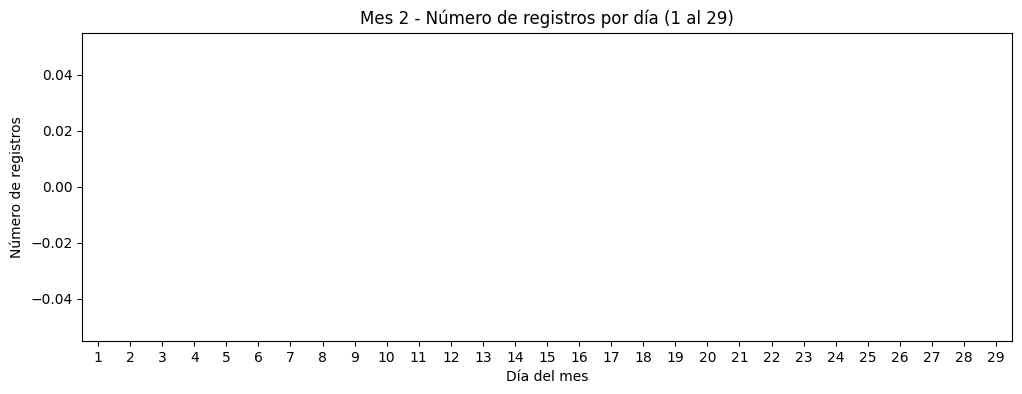

In [2]:
# Histograma (barras) del mes 2: número de registros por día
df_mes_2 = df.loc[df["mes"] == 2].copy()
# Conteo por truck_code en mes 2
conteo_por_camion_mes_2 = (
    df_mes_2["truck_code"]
    .value_counts(dropna=False)
    .sort_index()
)

print("Conteo por camión (mes 2):")
display(conteo_por_camion_mes_2)

# Si no existe px (por orden de ejecución de celdas), importarlo
if "px" not in globals():
    import plotly.express as px

if df_mes_2.empty:
    print("No hay registros para el mes 2.")
else:
    # Conteo por día y truck_code (1..29)
    registros_por_dia_truck_mes_2 = (
        df_mes_2.groupby(["u_day", "truck_code"])
        .size()
        .unstack(fill_value=0)
        .reindex(range(1, 30), fill_value=0)
    )

    # Colores consistentes con mes 1 (y color determinístico si aparece un truck nuevo)
    truck_ids_mes_2 = registros_por_dia_truck_mes_2.columns.tolist()
    colores_por_truck_mes_2 = {
        t: colores_por_truck.get(
            t,
            f"#{(int(pd.util.hash_pandas_object(pd.Index([t]), index=False).iloc[0]) & 0xFFFFFF):06x}"
        )
        for t in truck_ids_mes_2
    }

    # Formato largo para plotly
    plot_data_mes_2 = (
        registros_por_dia_truck_mes_2
        .reset_index(names="u_day")
        .melt(id_vars="u_day", var_name="truck_code", value_name="conteo")
    )

    fig_mes_2 = px.bar(
        plot_data_mes_2,
        x="u_day",
        y="conteo",
        color="truck_code",
        title="Mes 2 - Número de registros por día y truck_code (1 al 29)",
        labels={"u_day": "Día del mes", "conteo": "Número de registros", "truck_code": "truck_code"},
        color_discrete_map=colores_por_truck_mes_2
    )

    fig_mes_2.update_layout(
        barmode="stack",
        xaxis=dict(tickmode="linear", dtick=1),
        legend_title_text="truck_code"
    )
    fig_mes_2.update_traces(
        hovertemplate="Día %{x}<br>truck_code=%{fullData.name}<br>Conteo=%{y}<extra></extra>"
    )

    fig_mes_2.show()
registros_por_dia_mes_2 = (
    df_mes_2["u_day"]
    .value_counts()
    .sort_index()
)

print(f"Total de registros en mes 2: {len(df_mes_2)}")
display(registros_por_dia_mes_2)

# Asegurar que salgan los 29 días de febrero (incluye años bisiestos)
registros_por_dia_mes_2 = registros_por_dia_mes_2.reindex(range(1, 30), fill_value=0)

registros_por_dia_mes_2.plot(
    kind="bar",
    figsize=(12, 4),
    title="Mes 2 - Número de registros por día (1 al 29)",
    xlabel="Día del mes",
    ylabel="Número de registros",
    rot=0
)

In [5]:
# Histograma (barras) del mes 3: número de registros por día
df_mes_3 = df.loc[df["mes"] == 3].copy()

# Conteo por truck_code en mes 3
conteo_por_camion_mes_3 = (
    df_mes_3["truck_code"]
    .value_counts(dropna=False)
    .sort_index()
)
# Si no existe px (por orden de ejecución), importarlo
if "px" not in globals():
    import plotly.express as px

# Conteo por día y truck_code (apilado) para marzo (1..31)
registros_por_dia_truck_mes_3 = (
    df_mes_3.groupby(["u_day", "truck_code"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 32), fill_value=0)
)

# Colores consistentes con los ya definidos; si aparece un truck nuevo, color determinístico
truck_ids_mes_3 = registros_por_dia_truck_mes_3.columns.tolist()
colores_por_truck_mes_3 = {
    t: colores_por_truck.get(
        t,
        f"#{(int(pd.util.hash_pandas_object(pd.Index([t]), index=False).iloc[0]) & 0xFFFFFF):06x}"
    )
    for t in truck_ids_mes_3
}

# Formato largo para Plotly
plot_data_mes_3 = (
    registros_por_dia_truck_mes_3
    .reset_index(names="u_day")
    .melt(id_vars="u_day", var_name="truck_code", value_name="conteo")
)

fig_mes_3 = px.bar(
    plot_data_mes_3,
    x="u_day",
    y="conteo",
    color="truck_code",
    title="Mes 3 - Número de registros por día y truck_code (1 al 31)",
    labels={"u_day": "Día del mes", "conteo": "Número de registros", "truck_code": "truck_code"},
    color_discrete_map=colores_por_truck_mes_3
)

fig_mes_3.update_layout(
    barmode="stack",
    xaxis=dict(tickmode="linear", dtick=1),
    legend_title_text="truck_code"
)

fig_mes_3.update_traces(
    hovertemplate="Día %{x}<br>truck_code=%{fullData.name}<br>Conteo=%{y}<extra></extra>"
)

fig_mes_3.show()
print("Conteo por camión (mes 3):")
display(conteo_por_camion_mes_3)

registros_por_dia_mes_3 = (
    df_mes_3["u_day"]
    .value_counts()
    .sort_index()
)

print(f"Total de registros en mes 3: {len(df_mes_3)}")
display(registros_por_dia_mes_3)


Conteo por camión (mes 3):


truck_code
6162      73
6302      46
6611      88
7039      74
7044      68
7046      47
9428      61
9429      93
9631       2
12863    110
13011     87
13219     51
13221     82
Name: count, dtype: int64

Total de registros en mes 3: 882


u_day
4     23
5     47
6     29
7     41
8     29
10    38
11    53
12    37
13    42
14    33
15    35
18    40
19    46
20    30
21    50
22    25
24    36
25    43
26    46
27    47
28    51
29    28
31    33
Name: count, dtype: int64

In [7]:
# Histograma (barras) del mes 4: número de registros por día
df_mes_4 = df.loc[df["mes"] == 4].copy()
# Conteo por truck_code en mes 4
conteo_por_camion_mes_4 = (
    df_mes_4["truck_code"]
    .value_counts(dropna=False)
    .sort_index()
)

# Si no existe px (por orden de ejecución), importarlo
if "px" not in globals():
    import plotly.express as px

# Conteo por día y truck_code (apilado) para abril (1..30)
registros_por_dia_truck_mes_4 = (
    df_mes_4.groupby(["u_day", "truck_code"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 31), fill_value=0)
)

# Colores consistentes con meses anteriores; fallback determinístico si aparece un truck nuevo
truck_ids_mes_4 = registros_por_dia_truck_mes_4.columns.tolist()
colores_por_truck_mes_4 = {
    t: colores_por_truck.get(
        t,
        f"#{(int(pd.util.hash_pandas_object(pd.Index([t]), index=False).iloc[0]) & 0xFFFFFF):06x}"
    )
    for t in truck_ids_mes_4
}

# Formato largo para Plotly
plot_data_mes_4 = (
    registros_por_dia_truck_mes_4
    .reset_index(names="u_day")
    .melt(id_vars="u_day", var_name="truck_code", value_name="conteo")
)

fig_mes_4 = px.bar(
    plot_data_mes_4,
    x="u_day",
    y="conteo",
    color="truck_code",
    title="Mes 4 - Número de registros por día y truck_code (1 al 30)",
    labels={"u_day": "Día del mes", "conteo": "Número de registros", "truck_code": "truck_code"},
    color_discrete_map=colores_por_truck_mes_4
)

fig_mes_4.update_layout(
    barmode="stack",
    xaxis=dict(tickmode="linear", dtick=1),
    legend_title_text="truck_code"
)

fig_mes_4.update_traces(
    hovertemplate="Día %{x}<br>truck_code=%{fullData.name}<br>Conteo=%{y}<extra></extra>"
)

fig_mes_4.show()

print("Conteo por camión (mes 4):")
display(conteo_por_camion_mes_4)
registros_por_dia_mes_4 = (
    df_mes_4["u_day"]
    .value_counts()
    .sort_index()
)

print(f"Total de registros en mes 4: {len(df_mes_4)}")
display(registros_por_dia_mes_4)

Conteo por camión (mes 4):


truck_code
6162       2
6302     104
6611      95
7039      64
7044      72
7046      40
9428      96
9429      85
9631      46
12863    112
13011    103
13221    104
Name: count, dtype: int64

Total de registros en mes 4: 923


u_day
1     31
2     36
3     37
4     35
5     19
7     39
8     34
9     43
10    39
11    51
12    18
14    29
15    41
16    40
17    29
21    27
22    40
23    46
24    50
25    57
26    31
28    41
29    49
30    61
Name: count, dtype: int64

In [9]:
# Histograma (barras) del mes 5: número de registros por día
df_mes_5 = df.loc[df["mes"] == 5].copy()
# Conteo por truck_code en mes 5
conteo_por_camion_mes_5 = (
    df_mes_5["truck_code"]
    .value_counts(dropna=False)
    .sort_index()
)

# Si no existe px (por orden de ejecución), importarlo
if "px" not in globals():
    import plotly.express as px

# Conteo por día y truck_code (apilado) para mayo (1..31)
registros_por_dia_truck_mes_5 = (

    df_mes_5.groupby(["u_day", "truck_code"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 32), fill_value=0)
)

# Colores consistentes con meses anteriores; fallback determinístico si aparece un truck nuevo
truck_ids_mes_5 = registros_por_dia_truck_mes_5.columns.tolist()
colores_por_truck_mes_5 = {
    t: colores_por_truck.get(
        t,
        f"#{(int(pd.util.hash_pandas_object(pd.Index([t]), index=False).iloc[0]) & 0xFFFFFF):06x}"
    )
    for t in truck_ids_mes_5
}

# Formato largo para Plotly
plot_data_mes_5 = (
    registros_por_dia_truck_mes_5
    .reset_index(names="u_day")
    .melt(id_vars="u_day", var_name="truck_code", value_name="conteo")
)

fig_mes_5 = px.bar(
    plot_data_mes_5,
    x="u_day",
    y="conteo",
    color="truck_code",
    title="Mes 5 - Número de registros por día y truck_code (1 al 30)",
    labels={"u_day": "Día del mes", "conteo": "Número de registros", "truck_code": "truck_code"},
    color_discrete_map=colores_por_truck_mes_5
)

fig_mes_5.update_layout(
    barmode="stack",
    xaxis=dict(tickmode="linear", dtick=1),
    legend_title_text="truck_code"
)

fig_mes_5.update_traces(
    hovertemplate="Día %{x}<br>truck_code=%{fullData.name}<br>Conteo=%{y}<extra></extra>"
)

fig_mes_5.show()

print("Conteo por camión (mes 5):")
display(conteo_por_camion_mes_5)
registros_por_dia_mes_5 = (
    df_mes_5["u_day"]
    .value_counts()
    .sort_index()
)

print(f"Total de registros en mes 5: {len(df_mes_5)}")
display(registros_por_dia_mes_5)

Conteo por camión (mes 5):


truck_code
6162      17
6302      97
6603      46
6611      38
7039      33
7044      81
7046      54
9428      59
9429     102
9631      16
12863    113
13011     59
13022     54
13221     95
Name: count, dtype: int64

Total de registros en mes 5: 864


u_day
2     45
3     21
5     35
6     39
7     29
8     44
9     44
10    27
12    24
13    23
14    41
15    52
16    37
17    23
19    31
20    35
21    34
22    31
23    37
24    46
26    29
27    22
28    41
29    34
30    39
31     1
Name: count, dtype: int64

In [10]:
# Histograma (barras) del mes 6: número de registros por día
df_mes_6 = df.loc[df["mes"] == 6].copy()
# Conteo por truck_code en mes 6
conteo_por_camion_mes_6 = (
    df_mes_6["truck_code"]
    .value_counts(dropna=False)
    .sort_index()
)

# Si no existe px (por orden de ejecución), importarlo
if "px" not in globals():
    import plotly.express as px

# Conteo por día y truck_code (apilado) para junio (1..30)
registros_por_dia_truck_mes_6 = (

    df_mes_6.groupby(["u_day", "truck_code"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 31), fill_value=0)
)

# Colores consistentes con meses anteriores; fallback determinístico si aparece un truck nuevo
truck_ids_mes_6 = registros_por_dia_truck_mes_6.columns.tolist()
colores_por_truck_mes_6 = {
    t: colores_por_truck.get(
        t,
        f"#{(int(pd.util.hash_pandas_object(pd.Index([t]), index=False).iloc[0]) & 0xFFFFFF):06x}"
    )
    for t in truck_ids_mes_6
}

# Formato largo para Plotly
plot_data_mes_6 = (
    registros_por_dia_truck_mes_6
    .reset_index(names="u_day")
    .melt(id_vars="u_day", var_name="truck_code", value_name="conteo")
)

fig_mes_6 = px.bar(
    plot_data_mes_6,
    x="u_day",
    y="conteo",
    color="truck_code",
    title="Mes 6 - Número de registros por día y truck_code (1 al 30)",
    labels={"u_day": "Día del mes", "conteo": "Número de registros", "truck_code": "truck_code"},
    color_discrete_map=colores_por_truck_mes_6
)

fig_mes_6.update_layout(
    barmode="stack",
    xaxis=dict(tickmode="linear", dtick=1),
    legend_title_text="truck_code"
)

fig_mes_6.update_traces(
    hovertemplate="Día %{x}<br>truck_code=%{fullData.name}<br>Conteo=%{y}<extra></extra>"
)

fig_mes_6.show()

print("Conteo por camión (mes 6):")
display(conteo_por_camion_mes_6)
registros_por_dia_mes_6 = (
    df_mes_6["u_day"]
    .value_counts()
    .sort_index()
)

print(f"Total de registros en mes 6: {len(df_mes_6)}")
display(registros_por_dia_mes_6)

Conteo por camión (mes 6):


truck_code
6162     27
6302     72
6600     37
6603     69
7044     68
7046     65
9429     89
9631     81
12863    93
13011     2
13022    79
13221    93
Name: count, dtype: int64

Total de registros en mes 6: 775


u_day
2     49
3     50
4     62
5     37
6     29
7     30
9     36
10    40
11    50
12    45
13    22
14     8
16    12
17    26
18    32
19    41
20    27
21    21
23    26
24    16
25    26
26    30
27    30
28    20
30    10
Name: count, dtype: int64

In [11]:
# Histograma (barras) del mes 7: número de registros por día
df_mes_7 = df.loc[df["mes"] == 7].copy()
# Conteo por truck_code en mes 7
conteo_por_camion_mes_7 = (
    df_mes_7["truck_code"]
    .value_counts(dropna=False)
    .sort_index()
)

# Si no existe px (por orden de ejecución), importarlo
if "px" not in globals():
    import plotly.express as px

# Conteo por día y truck_code (apilado) para julio (1..30)
registros_por_dia_truck_mes_7 = (

    df_mes_4.groupby(["u_day", "truck_code"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 32), fill_value=0)
)

# Colores consistentes con meses anteriores; fallback determinístico si aparece un truck nuevo
truck_ids_mes_7 = registros_por_dia_truck_mes_7.columns.tolist()
colores_por_truck_mes_7 = {
    t: colores_por_truck.get(
        t,
        f"#{(int(pd.util.hash_pandas_object(pd.Index([t]), index=False).iloc[0]) & 0xFFFFFF):06x}"
    )
    for t in truck_ids_mes_7
}

# Formato largo para Plotly
plot_data_mes_7 = (
    registros_por_dia_truck_mes_7
    .reset_index(names="u_day")
    .melt(id_vars="u_day", var_name="truck_code", value_name="conteo")
)

fig_mes_7 = px.bar(
    plot_data_mes_7,
    x="u_day",
    y="conteo",
    color="truck_code",
    title="Mes 7 - Número de registros por día y truck_code (1 al 30)",
    labels={"u_day": "Día del mes", "conteo": "Número de registros", "truck_code": "truck_code"},
    color_discrete_map=colores_por_truck_mes_7
)

fig_mes_7.update_layout(
    barmode="stack",
    xaxis=dict(tickmode="linear", dtick=1),
    legend_title_text="truck_code"
)

fig_mes_7.update_traces(
    hovertemplate="Día %{x}<br>truck_code=%{fullData.name}<br>Conteo=%{y}<extra></extra>"
)

fig_mes_7.show()

print("Conteo por camión (mes 7):")
display(conteo_por_camion_mes_7)
registros_por_dia_mes_7 = (
    df_mes_7["u_day"]
    .value_counts()
    .sort_index()
)

print(f"Total de registros en mes 7: {len(df_mes_7)}")
display(registros_por_dia_mes_7)

Conteo por camión (mes 7):


truck_code
6302      61
6603      45
6608      31
7044       6
7046     103
9428       1
9429     116
9631      62
12863     89
13011      6
13022    103
13221    101
Name: count, dtype: int64

Total de registros en mes 7: 724


u_day
1     17
2      6
3     16
4     24
5     33
7     22
8     32
9     44
10    24
11    45
12    17
14    24
15    23
16    21
17    32
18    33
19    22
21    23
22    31
23    29
24    24
25    38
26    27
28    39
29    30
30    23
31    25
Name: count, dtype: int64

In [12]:
# Histograma (barras) del mes 8: número de registros por día
df_mes_8 = df.loc[df["mes"] == 8].copy()
# Conteo por truck_code en mes 8
conteo_por_camion_mes_8 = (
    df_mes_8["truck_code"]
    .value_counts(dropna=False)
    .sort_index()
)

# Si no existe px (por orden de ejecución), importarlo
if "px" not in globals():
    import plotly.express as px

# Conteo por día y truck_code (apilado) para agosto (1..30)
registros_por_dia_truck_mes_8 = (

    df_mes_8.groupby(["u_day", "truck_code"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 32), fill_value=0)
)

# Colores consistentes con meses anteriores; fallback determinístico si aparece un truck nuevo
truck_ids_mes_8 = registros_por_dia_truck_mes_8.columns.tolist()
colores_por_truck_mes_8 = {
    t: colores_por_truck.get(
        t,
        f"#{(int(pd.util.hash_pandas_object(pd.Index([t]), index=False).iloc[0]) & 0xFFFFFF):06x}"
    )
    for t in truck_ids_mes_8
}

# Formato largo para Plotly
plot_data_mes_8 = (
    registros_por_dia_truck_mes_8
    .reset_index(names="u_day")
    .melt(id_vars="u_day", var_name="truck_code", value_name="conteo")
)

fig_mes_8 = px.bar(
    plot_data_mes_8,
    x="u_day",
    y="conteo",
    color="truck_code",
    title="Mes 8 - Número de registros por día y truck_code (1 al 30)",
    labels={"u_day": "Día del mes", "conteo": "Número de registros", "truck_code": "truck_code"},
    color_discrete_map=colores_por_truck_mes_8
)

fig_mes_8.update_layout(
    barmode="stack",
    xaxis=dict(tickmode="linear", dtick=1),
    legend_title_text="truck_code"
)

fig_mes_8.update_traces(
    hovertemplate="Día %{x}<br>truck_code=%{fullData.name}<br>Conteo=%{y}<extra></extra>"
)

fig_mes_8.show()

print("Conteo por camión (mes 8):")
display(conteo_por_camion_mes_8)
registros_por_dia_mes_8 = (
    df_mes_8["u_day"]
    .value_counts()
    .sort_index()
)

print(f"Total de registros en mes 8: {len(df_mes_8)}")
display(registros_por_dia_mes_8)

Conteo por camión (mes 8):


truck_code
6162      79
6603      47
6608      89
6611       1
7044      96
7046      18
9429      62
9631      88
12863     94
13022    102
13219      1
13221     84
Name: count, dtype: int64

Total de registros en mes 8: 761


u_day
1     27
2     18
4     19
5     17
6     35
7     24
8     31
9     23
11    18
12    27
13    33
14    35
15    44
16    18
18    22
19    37
20    31
21    45
22    47
23    28
25    19
26    35
27    37
28    32
29    41
30    18
Name: count, dtype: int64

In [13]:
# Histograma (barras) del mes 9: número de registros por día
df_mes_9 = df.loc[df["mes"] == 9].copy()
# Conteo por truck_code en mes 9
conteo_por_camion_mes_9 = (
    df_mes_9["truck_code"]
    .value_counts(dropna=False)
    .sort_index()
)

# Si no existe px (por orden de ejecución), importarlo
if "px" not in globals():
    import plotly.express as px

# Conteo por día y truck_code (apilado) para septiembre (1..30)
registros_por_dia_truck_mes_9 = (

    df_mes_9.groupby(["u_day", "truck_code"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 31), fill_value=0)
)

# Colores consistentes con meses anteriores; fallback determinístico si aparece un truck nuevo
truck_ids_mes_9 = registros_por_dia_truck_mes_9.columns.tolist()
colores_por_truck_mes_9 = {
    t: colores_por_truck.get(
        t,
        f"#{(int(pd.util.hash_pandas_object(pd.Index([t]), index=False).iloc[0]) & 0xFFFFFF):06x}"
    )
    for t in truck_ids_mes_9
}

# Formato largo para Plotly
plot_data_mes_9 = (
    registros_por_dia_truck_mes_9   
    .reset_index(names="u_day")
    .melt(id_vars="u_day", var_name="truck_code", value_name="conteo")
)

fig_mes_9 = px.bar(
    plot_data_mes_9,
    x="u_day",
    y="conteo",
    color="truck_code",
    title="Mes 9 - Número de registros por día y truck_code (1 al 30)",
    labels={"u_day": "Día del mes", "conteo": "Número de registros", "truck_code": "truck_code"},
    color_discrete_map=colores_por_truck_mes_9
)

fig_mes_9.update_layout(
    barmode="stack",
    xaxis=dict(tickmode="linear", dtick=1),
    legend_title_text="truck_code"
)

fig_mes_9.update_traces(
    hovertemplate="Día %{x}<br>truck_code=%{fullData.name}<br>Conteo=%{y}<extra></extra>"
)

fig_mes_9.show()

print("Conteo por camión (mes 9):")
display(conteo_por_camion_mes_9)
registros_por_dia_mes_9 = (
    df_mes_9["u_day"]
    .value_counts()
    .sort_index()
)

print(f"Total de registros en mes 9: {len(df_mes_9)}")
display(registros_por_dia_mes_9)

Conteo por camión (mes 9):


truck_code
6162      78
6302      25
6603      98
6608      69
7044      68
7046      40
9429      10
9631      47
12863     79
13011      1
13014     30
13022    106
13218     20
13221     73
Name: count, dtype: int64

Total de registros en mes 9: 744


u_day
1     15
2     27
3     33
4     37
5     31
6     19
8     28
9     25
10    38
11    28
12    35
13    23
15    26
17    38
18    28
19    43
20    19
22    26
23    34
24    43
25    21
26    44
27    14
29    20
30    49
Name: count, dtype: int64

In [15]:
# Histograma (barras) del mes 10: número de registros por día
df_mes_10 = df.loc[df["mes"] == 10].copy()
# Conteo por truck_code en mes 10
conteo_por_camion_mes_10 = (
    df_mes_10["truck_code"]
    .value_counts(dropna=False)
    .sort_index()
)

# Si no existe px (por orden de ejecución), importarlo
if "px" not in globals():
    import plotly.express as px

# Conteo por día y truck_code (apilado) para octubre (1..30)
registros_por_dia_truck_mes_10 = (
    df_mes_10.groupby(["u_day", "truck_code"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 32), fill_value=0)
)

# Colores consistentes con meses anteriores; fallback determinístico si aparece un truck nuevo
truck_ids_mes_10 = registros_por_dia_truck_mes_10.columns.tolist()
colores_por_truck_mes_10 = {
    t: colores_por_truck.get(
        t,
        f"#{(int(pd.util.hash_pandas_object(pd.Index([t]), index=False).iloc[0]) & 0xFFFFFF):06x}"
    )
    for t in truck_ids_mes_10
}

# Formato largo para Plotly
plot_data_mes_10 = (
    registros_por_dia_truck_mes_10
    .reset_index(names="u_day")
    .melt(id_vars="u_day", var_name="truck_code", value_name="conteo")
)

fig_mes_10 = px.bar(
    plot_data_mes_10,
    x="u_day",
    y="conteo",
    color="truck_code",
    title="Mes 10 - Número de registros por día y truck_code (1 al 30)",
    labels={"u_day": "Día del mes", "conteo": "Número de registros", "truck_code": "truck_code"},
    color_discrete_map=colores_por_truck_mes_10
)

fig_mes_10.update_layout(
    barmode="stack",
    xaxis=dict(tickmode="linear", dtick=1),
    legend_title_text="truck_code"
)

fig_mes_10.update_traces(
    hovertemplate="Día %{x}<br>truck_code=%{fullData.name}<br>Conteo=%{y}<extra></extra>"
)

fig_mes_10.show()

print("Conteo por camión (mes 10):")
display(conteo_por_camion_mes_10)
registros_por_dia_mes_10 = (
    df_mes_10["u_day"]
    .value_counts()
    .sort_index()
)

print(f"Total de registros en mes 10: {len(df_mes_10)}")
display(registros_por_dia_mes_10)

Conteo por camión (mes 10):


truck_code
6162      94
6302     100
6603      83
7044     112
7046      54
9428       1
9429     116
9631      62
12863     86
13014    107
13022     49
13218     95
13221     92
Name: count, dtype: int64

Total de registros en mes 10: 1051


u_day
1     38
2     48
3     39
4     19
6     34
7     41
8     46
9     36
10    40
11    21
13    27
14    44
15    49
16    61
17    49
18    33
20    27
21    36
22    41
23    41
24    40
25    24
27    33
28    40
29    56
30    42
31    46
Name: count, dtype: int64

In [17]:
# Histograma (barras) del mes 11: número de registros por día
df_mes_11 = df.loc[df["mes"] == 11].copy()
# Conteo por truck_code en mes 11
conteo_por_camion_mes_11 = (
    df_mes_11["truck_code"]
    .value_counts(dropna=False)
    .sort_index()
)

# Si no existe px (por orden de ejecución), importarlo
if "px" not in globals():
    import plotly.express as px

# Conteo por día y truck_code (apilado) para noviembre (1..30)
registros_por_dia_truck_mes_11 = (
    df_mes_11.groupby(["u_day", "truck_code"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 31), fill_value=0)
)

# Colores consistentes con meses anteriores; fallback determinístico si aparece un truck nuevo
truck_ids_mes_11 = registros_por_dia_truck_mes_11.columns.tolist()
colores_por_truck_mes_11 = {
    t: colores_por_truck.get(
        t,
        f"#{(int(pd.util.hash_pandas_object(pd.Index([t]), index=False).iloc[0]) & 0xFFFFFF):06x}"
    )
    for t in truck_ids_mes_11
}

# Formato largo para Plotly
plot_data_mes_11 = (
    registros_por_dia_truck_mes_11
    .reset_index(names="u_day")
    .melt(id_vars="u_day", var_name="truck_code", value_name="conteo")
)

fig_mes_11 = px.bar(
    plot_data_mes_11,
    x="u_day",
    y="conteo",
    color="truck_code",
    title="Mes 11 - Número de registros por día y truck_code (1 al 30)",
    labels={"u_day": "Día del mes", "conteo": "Número de registros", "truck_code": "truck_code"},
    color_discrete_map=colores_por_truck_mes_11
)

fig_mes_11.update_layout(
    barmode="stack",
    xaxis=dict(tickmode="linear", dtick=1),
    legend_title_text="truck_code"
)

fig_mes_11.update_traces(
    hovertemplate="Día %{x}<br>truck_code=%{fullData.name}<br>Conteo=%{y}<extra></extra>"
)

fig_mes_11.show()

print("Conteo por camión (mes 11):")
display(conteo_por_camion_mes_11)
registros_por_dia_mes_11 = (
    df_mes_11["u_day"]
    .value_counts()
    .sort_index()
)

print(f"Total de registros en mes 11: {len(df_mes_11)}")
display(registros_por_dia_mes_11)

Conteo por camión (mes 11):


truck_code
6161     21
6162     55
6302     67
6603     79
6608     38
7044     74
7046     19
9429     69
9631     45
12863    72
13011     1
13014    86
13022    80
13218    63
13221    85
Name: count, dtype: int64

Total de registros en mes 11: 854


u_day
1     36
3     16
4     28
5     26
6     49
7     33
8     22
10    47
11    46
12    30
13    46
14    28
15    31
18    38
19    41
20    58
21    37
22    39
24    18
25    31
26    33
27    64
28    34
29    23
Name: count, dtype: int64

In [18]:
# Histograma (barras) del mes 12: número de registros por día
df_mes_12 = df.loc[df["mes"] == 12].copy()
# Conteo por truck_code en mes 12
conteo_por_camion_mes_12 = (
    df_mes_12["truck_code"]
    .value_counts(dropna=False)
    .sort_index()
)

# Si no existe px (por orden de ejecución), importarlo
if "px" not in globals():
    import plotly.express as px

# Conteo por día y truck_code (apilado) para diciembre (1..30)
registros_por_dia_truck_mes_12 = (

    df_mes_12.groupby(["u_day", "truck_code"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 32), fill_value=0)
)

# Colores consistentes con meses anteriores; fallback determinístico si aparece un truck nuevo
truck_ids_mes_12 = registros_por_dia_truck_mes_12.columns.tolist()
colores_por_truck_mes_12 = {
    t: colores_por_truck.get(
        t,
        f"#{(int(pd.util.hash_pandas_object(pd.Index([t]), index=False).iloc[0]) & 0xFFFFFF):06x}"
    )
    for t in truck_ids_mes_12
}

# Formato largo para Plotly
plot_data_mes_12 = (
    registros_por_dia_truck_mes_12
    .reset_index(names="u_day")
    .melt(id_vars="u_day", var_name="truck_code", value_name="conteo")
)

fig_mes_12 = px.bar(
    plot_data_mes_12,
    x="u_day",
    y="conteo",
    color="truck_code",
    title="Mes 12 - Número de registros por día y truck_code (1 al 31)",
    labels={"u_day": "Día del mes", "conteo": "Número de registros", "truck_code": "truck_code"},
    color_discrete_map=colores_por_truck_mes_12
)

fig_mes_12.update_layout(
    barmode="stack",
    xaxis=dict(tickmode="linear", dtick=1),
    legend_title_text="truck_code"
)

fig_mes_12.update_traces(
    hovertemplate="Día %{x}<br>truck_code=%{fullData.name}<br>Conteo=%{y}<extra></extra>"
)

fig_mes_12.show()

print("Conteo por camión (mes 12):")
display(conteo_por_camion_mes_12)
registros_por_dia_mes_12 = (
    df_mes_12["u_day"]
    .value_counts()
    .sort_index()
)

print(f"Total de registros en mes 12: {len(df_mes_12)}")
display(registros_por_dia_mes_12)

Conteo por camión (mes 12):


truck_code
6162     62
6302     17
6603     16
6608     95
7044     76
9429     85
9631     39
12863    85
13014    93
13022    83
13218    71
13221    90
Name: count, dtype: int64

Total de registros en mes 12: 812


u_day
1     21
2     43
3     49
4     46
5     46
6     19
8     38
9     33
10    42
11    41
12    30
13    21
15    34
16    41
17    37
18    34
19    33
20    16
22    26
23    35
24    17
26    13
27    16
29    28
30    36
31    17
Name: count, dtype: int64

In [22]:
# Total de registros por mes (histograma de barras)
if "df" not in globals():
    df = pd.read_csv("cleaned_data.csv")

if "mes" not in df.columns:
    df["mes"] = pd.to_datetime(df["dispatch_dt"], errors="coerce").dt.month

if "px" not in globals():
    import plotly.express as px

registros_por_mes = (
    df["mes"]
    .value_counts(dropna=True)
    .sort_index()
    .reindex(range(1, 13), fill_value=0)
)

fig = px.bar(
    x=registros_por_mes.index,
    y=registros_por_mes.values,
    title="Total de registros por mes",
    labels={"x": "Mes", "y": "Total de registros"},
    text=registros_por_mes.values
)

fig.update_layout(xaxis=dict(tickmode="linear", dtick=1))
fig.update_traces(hovertemplate="Mes %{x}<br>Total=%{y}<extra></extra>")
fig.show()

display(registros_por_mes.rename("total_registros"))

# Desglose por mes separado por colores según truck_code
registros_por_mes_camion = (
    df.dropna(subset=["mes", "truck_code"])
    .groupby(["mes", "truck_code"])
    .size()
    .rename("total_registros")
    .reset_index()
)

# Colores consistentes (usa los ya definidos si existen)
truck_ids_mes = sorted(registros_por_mes_camion["truck_code"].unique())
colores_por_truck_mes = {
    t: (
        colores_por_truck[t]
        if "colores_por_truck" in globals() and t in colores_por_truck
        else f"#{(int(pd.util.hash_pandas_object(pd.Index([t]), index=False).iloc[0]) & 0xFFFFFF):06x}"
    )
    for t in truck_ids_mes
}

fig_camion = px.bar(
    registros_por_mes_camion,
    x="mes",
    y="total_registros",
    color="truck_code",
    barmode="stack",
    title="Total de registros por mes separado por camión",
    labels={"mes": "Mes", "total_registros": "Total de registros", "truck_code": "Camión"},
    color_discrete_map=colores_por_truck_mes
)

fig_camion.update_layout(xaxis=dict(tickmode="linear", dtick=1), legend_title_text="Camión")
fig_camion.update_traces(hovertemplate="Mes %{x}<br>Camión=%{fullData.name}<br>Total=%{y}<extra></extra>")
fig_camion.show()

mes
1      170
2        0
3      882
4      923
5      864
6      775
7      724
8      761
9      744
10    1051
11     854
12     812
Name: total_registros, dtype: int64

In [23]:
# Histograma de horas más demandadas (conteo de registros por hora)

if "df" not in globals():
    df = pd.read_csv("cleaned_data.csv")

# Si no existe px por el orden de ejecución, importarlo
if "px" not in globals():
    import plotly.express as px

# Convertir dispatch_dt a hora (funciona si viene como datetime completo o como HH:MM:SS)
horas = pd.to_datetime(df["dispatch_dt"], errors="coerce").dt.hour

registros_por_hora = (
    horas.value_counts(dropna=True)
    .sort_index()
    .reindex(range(24), fill_value=0)
)

print("Top 5 horas más demandadas:")
display(registros_por_hora.sort_values(ascending=False).head(5).rename("total_registros"))

fig_horas = px.bar(
    x=registros_por_hora.index,
    y=registros_por_hora.values,
    title="Histograma: demanda por hora del día",
    labels={"x": "Hora del día", "y": "Número de registros"},
    text=registros_por_hora.values
)

fig_horas.update_layout(xaxis=dict(tickmode="linear", dtick=1))
fig_horas.update_traces(hovertemplate="Hora %{x}:00<br>Total=%{y}<extra></extra>")
fig_horas.show()

Top 5 horas más demandadas:


Top 5 horas más demandadas:


dispatch_dt
10    1039
9      971
11     962
8      904
12     838
Name: total_registros, dtype: int64

Top 5 horas más demandadas:


dispatch_dt
10    1039
9      971
11     962
8      904
12     838
Name: total_registros, dtype: int64

In [24]:
df.to_csv("explored_data.csv", index=False)